# Continuity Bench Results Analysis

In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load metrics
df = pd.read_csv('../results/raw_metrics.csv')

# Load conversation lengths
with open('../testsuite/conversations.json', 'r', encoding='utf-8') as f:
    conversations = json.load(f)
    
conv_lengths = {c['id']: len(c['turns']) for c in conversations}
df['turn_count'] = df['conversation_id'].map(conv_lengths)

# Categorize lengths
def categorize_length(turns):
    if turns <= 5: return 'Short (<=5)'
    if turns <= 10: return 'Medium (6-10)'
    return 'Long (>10)'
    
df['length_category'] = df['turn_count'].apply(categorize_length)


## 1. Continuity Preservation Rate (CPR)

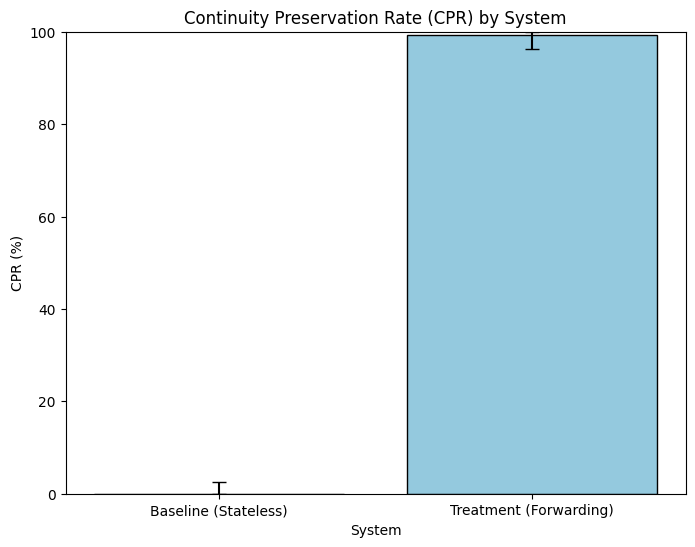

In [2]:
from statsmodels.stats.proportion import proportion_confint

# Calculate CPR and CIs
cpr_data = []
for system in ['baseline', 'treatment']:
    sys_df = df[(df['system'] == system) & (df['failed_over'] == True)]
    total = len(sys_df)
    success = sys_df['preserved'].sum()
    cpr = success / total * 100 if total > 0 else 0
    
    ci_low, ci_high = proportion_confint(success, total, method='wilson')
    
    cpr_data.append({
        'System': 'Baseline (Stateless)' if system == 'baseline' else 'Treatment (Forwarding)',
        'CPR (%)': cpr,
        'Yerr_Low': cpr - (ci_low * 100),
        'Yerr_High': (ci_high * 100) - cpr
    })
    
cpr_df = pd.DataFrame(cpr_data)

plt.figure(figsize=(8, 6))
sns.barplot(data=cpr_df, x='System', y='CPR (%)', color='skyblue', edgecolor='black')
plt.errorbar(x=cpr_df['System'], y=cpr_df['CPR (%)'], 
             yerr=[cpr_df['Yerr_Low'], cpr_df['Yerr_High']], 
             fmt='none', c='black', capsize=5)

plt.title('Continuity Preservation Rate (CPR) by System')
plt.ylabel('CPR (%)')
plt.ylim(0, 100)
plt.savefig('../results/figures/cpr_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


## 2. Continuity Latency Overhead (CLO)

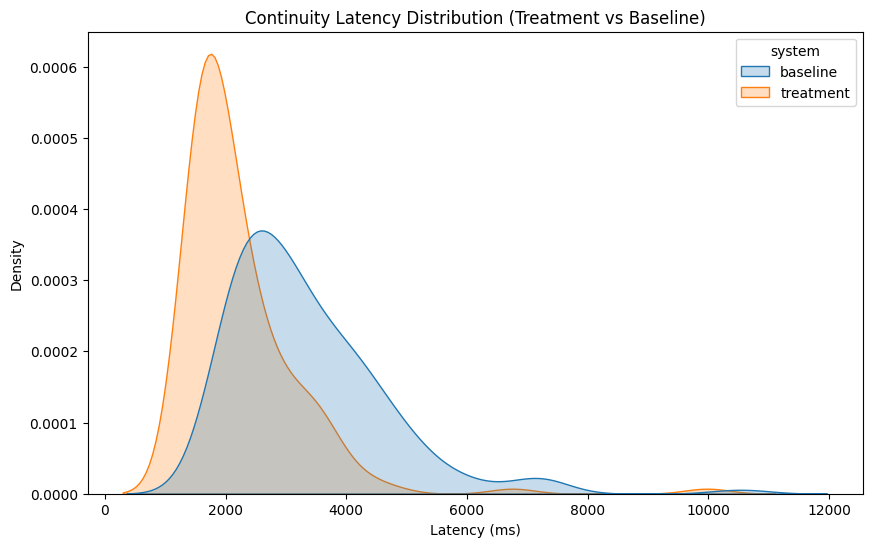

In [3]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df[df['failed_over'] == True], x='latency_ms', hue='system', fill=True, common_norm=False)
plt.title('Continuity Latency Distribution (Treatment vs Baseline)')
plt.xlabel('Latency (ms)')
plt.ylabel('Density')
plt.savefig('../results/figures/latency_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


## 3. CPR by Conversation Length

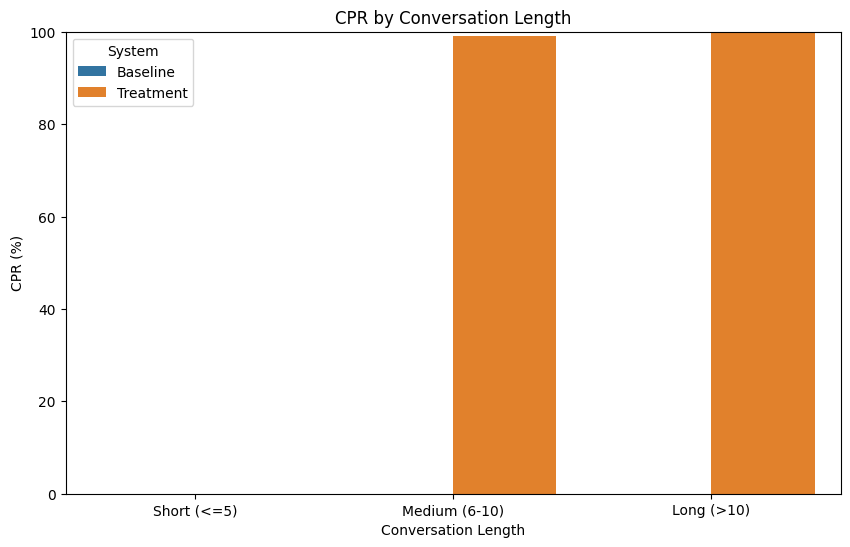

In [4]:
length_order = ['Short (<=5)', 'Medium (6-10)', 'Long (>10)']
len_data = []

for system in ['baseline', 'treatment']:
    for length in length_order:
        sys_df = df[(df['system'] == system) & (df['failed_over'] == True) & (df['length_category'] == length)]
        total = len(sys_df)
        success = sys_df['preserved'].sum()
        cpr = success / total * 100 if total > 0 else 0
        
        len_data.append({
            'System': 'Baseline' if system == 'baseline' else 'Treatment',
            'Conversation Length': length,
            'CPR (%)': cpr
        })

len_df = pd.DataFrame(len_data)

plt.figure(figsize=(10, 6))
sns.barplot(data=len_df, x='Conversation Length', y='CPR (%)', hue='System', order=length_order)
plt.title('CPR by Conversation Length')
plt.ylabel('CPR (%)')
plt.ylim(0, 100)
plt.savefig('../results/figures/cpr_by_length.png', dpi=300, bbox_inches='tight')
plt.show()
